In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [3]:
#Step1:Create dataset

data = {
    'Experience': [1, 2, 3, 4, 5, 6, 7],
    'Salary': [45000, 50000, 60000, 80000, 110000, 150000, 200000]
}

df=pd.DataFrame(data)
print("Dataset:\n",df)


Dataset:
    Experience  Salary
0           1   45000
1           2   50000
2           3   60000
3           4   80000
4           5  110000
5           6  150000
6           7  200000


In [4]:
#Step2:Define features (X) and target(y)---

X=df[['Experience']].values
y=df['Salary'].values.reshape(-1,1)

In [7]:
#step3:Features scaling(very important for svr)
sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)

In [8]:
#Step4:Train the SVR model---

svr_model =SVR(kernel='rbf')  #rbf = radial basis function
svr_model.fit(X_scaled, y_scaled.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [10]:
#STEP5:Predict for plotting :
X_range = np.linspace(min(X),max(X),100).reshape(-1,1)
y_pred_scaled = svr_model.predict(sc_X.transform(X_range))
y_pred =sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))

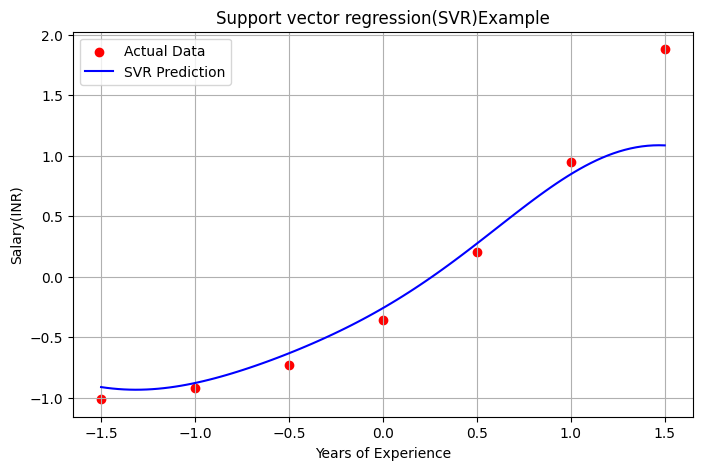

In [11]:
#Step6:PLOT thE result 
plt.figure(figsize=(8,5))
plt.scatter(X,y, color='red',label='Actual Data')
plt.plot(X_range ,y_pred,color='blue',label='SVR Prediction')
plt.title("Support vector regression(SVR)Example")
plt.xlabel("Years of Experience")
plt.ylabel("Salary(INR)")
plt.legend()
plt.grid(True)
plt.show()